In [79]:
using LinearAlgebra
using Plots
using Printf

# Funções Auxiliares

In [53]:
function converge_ponto_fixo(y_atual, t_atual, iterador, tol)
    y_prox = iterador(y_atual, t_atual)
    
    while(norm(y_prox - y_atual) > tol)
        y_atual = y_prox
        y_prox = iterador(y_atual, t_atual)
    end

    return y_prox
end

converge_ponto_fixo (generic function with 1 method)

In [81]:
function sol_plot(vec_sol, t_interval, t_steps)
    plot_result = plot(title=@sprintf("N = %d", t_steps))
    t_0 = t_interval[1]
    t_f = t_interval[2]
    k = (t_f - t_0)/t_steps
    
    dims = size(vec_sol)[1]
    for i in 1:dims
        plot!(plot_result, t_0:k:t_f, vec_sol[i, :])
    end

    return plot_result
end

sol_plot (generic function with 1 method)

# Métodos

In [52]:
function euler_implicito(f, k, vecs_y0, t_n, tol=10e-6)
    y_0 = vecs_y0[:, 1]
    
    iterador = (y, t) -> y_0 + k .* f(y, t)
    y_final = converge_ponto_fixo(y_0, t_n, iterador, tol)
    
    return y_final
end

euler_implicito (generic function with 2 methods)

# Função Principal

In [46]:
function diferencas_finitas(f, t_interval, t_steps, vecs_y0, metodo)
    t_0, t_f = t_interval
    k = (t_f - t_0)/t_steps

    vecs_sol = copy(vecs_y0)
    for t_n in (t_0+k):k:t_f
        sol = metodo(f, k, vecs_y0, t_n)
        vecs_sol = hcat(vecs_sol, sol)

        vecs_y0 = hcat(vecs_y0, sol)[:, 2:end]        
    end

    return vecs_sol
end

diferencas_finitas (generic function with 1 method)

# Exemplos

## 1 - Sistema Lotka-Volterra

In [75]:
f(y, t) = [ 1.2*y[1] - 0.6*y[1]*y[2], 
           -0.8*y[2] + 0.3*y[1]*y[2]]

t_interval = [0, 30]
vec_y0 = [2.0; 1.0]

t_0 = t_interval[1]
t_f = t_interval[2];

### Euler Implicito

2×6 Matrix{Float64}:
 2.0   Inf  NaN  NaN  NaN  NaN
 1.0  NaN   NaN  NaN  NaN  NaN

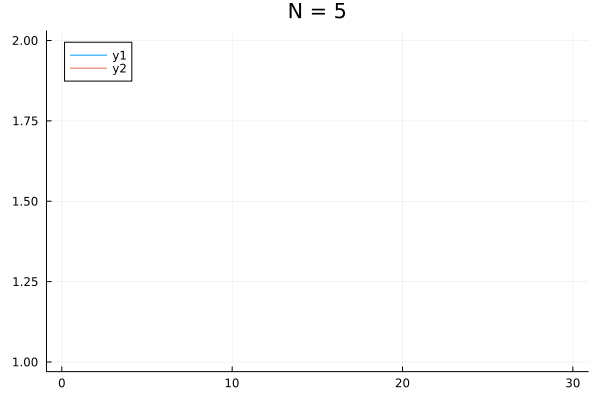

2×11 Matrix{Float64}:
 2.0   Inf  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
 1.0  NaN   NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN

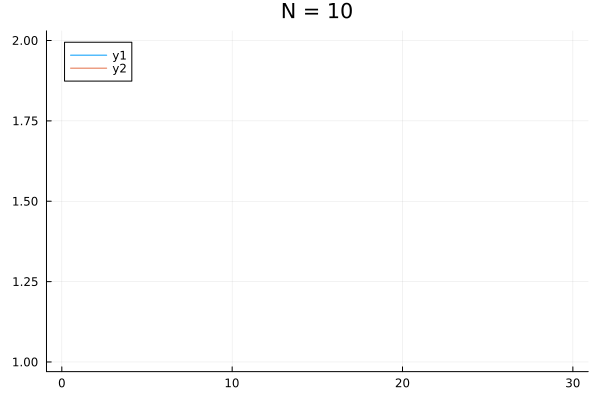

2×21 Matrix{Float64}:
 2.0   Inf  NaN  NaN  NaN  NaN  NaN  …  NaN  NaN  NaN  NaN  NaN  NaN  NaN
 1.0  NaN   NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN

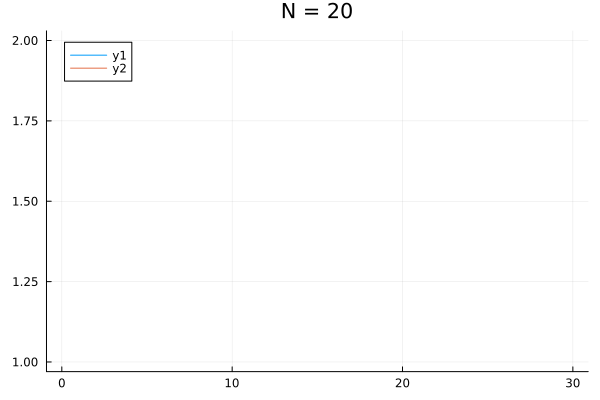

2×201 Matrix{Float64}:
 2.0  2.20226  2.42749   2.67564  …  2.64241  2.60578  2.57176  2.54091
 1.0  0.97953  0.969099  0.96949     2.16207  2.15616  2.14699  2.13491

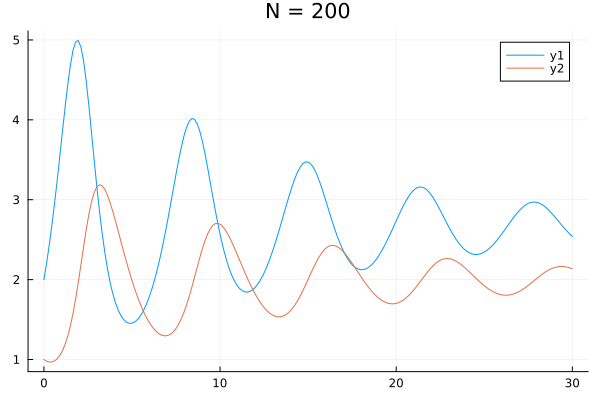

In [83]:
vec_t_steps = [5, 10, 20, 200]

for t_steps in vec_t_steps
    k = (t_f - t_0)/t_steps
    t_discrete = t_0:k:t_f
    
    vec_sol = diferencas_finitas(f, t_interval, t_steps, vec_y0, euler_implicito)
    final_plot = sol_plot(vec_sol, t_interval, t_steps) 
    display(vec_sol)
    display(final_plot)
end

### Trapézios

### Ponto Médio

### Adams-Bashforth de 2 passos

### Adams-Moulton de 2 passos